In [1]:
import warnings
warnings.filterwarnings("ignore")

import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNetCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)


In [2]:
DATA_PATH = "HBSC_data/HBSC2018OAed1.1.csv"
GROUPINGS_PATH = "HBSC_data/hbsc_variable_groupings.xlsx"
OUTPUT_PREFIX = "benrfv2"
AGE_MIN = 13.0
AGE_MAX = 16.5
TARGET = "distress_score_100"
N_OOS_RUNS = 5
TEST_SIZE = 0.20
RANDOM_SEEDS = [11, 23, 37, 49, 61]
MIN_STRATUM_COUNT = 30


In [3]:
def cronbach_alpha(df_items):
    items = df_items.dropna().copy()
    k = items.shape[1]
    if k <= 1:
        return np.nan
    item_variances = items.var(axis=0, ddof=1)
    total_variance = items.sum(axis=1).var(ddof=1)
    if total_variance == 0:
        return np.nan
    return (k / (k - 1)) * (1 - item_variances.sum() / total_variance)


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def print_header(title):
    print("\n" + "=" * len(title))
    print(title)
    print("=" * len(title))


def clean_text(value):
    if pd.isna(value):
        return ""
    return str(value).strip().strip("'").strip()


def slugify_group(name):
    slug = re.sub(r"[^0-9a-zA-Z]+", "_", clean_text(name).lower()).strip("_")
    return slug or "unnamed"


def first_nonempty(values, default=""):
    for value in values:
        value = clean_text(value)
        if value:
            return value
    return default


def load_feature_plan(path):
    plan = pd.read_excel(path).iloc[:, :6].copy()
    plan.columns = [
        "hbsc_var",
        "new_group",
        "aggregation_method",
        "new_question",
        "omit_for_modelling",
        "long_term_var",
    ]
    for col in plan.columns:
        plan[col] = plan[col].map(clean_text)
    plan = plan[plan["hbsc_var"] != ""].reset_index(drop=True)
    return plan


def aggregate_feature(df_source, source_cols, method):
    numeric = pd.DataFrame(index=df_source.index)
    for col in source_cols:
        if col in df_source.columns:
            numeric[col] = pd.to_numeric(df_source[col], errors="coerce")
        else:
            numeric[col] = np.nan

    if method == "mean":
        return numeric.mean(axis=1, skipna=True)

    if method == "sum - 2":
        counts = numeric.notna().sum(axis=1)
        summed = numeric.sum(axis=1, min_count=1) - counts
        summed[counts == 0] = np.nan
        return summed

    if method == "take the most frequent":
        return numeric.max(axis=1, skipna=True)

    if method == "take the most frequent out of all the symptoms":
        return numeric.min(axis=1, skipna=True)

    if method == "at least 1 yes = new yes":
        any_nonmissing = numeric.notna().any(axis=1)
        any_yes = numeric.eq(1).any(axis=1)
        out = pd.Series(np.nan, index=numeric.index, dtype=float)
        out[any_nonmissing] = 2.0
        out[any_yes] = 1.0
        return out

    if not method and len(source_cols) == 1:
        return numeric.iloc[:, 0]

    raise ValueError(f"Unsupported aggregation method: {method!r} for {source_cols}")


def build_feature_matrix(df_source, feature_plan):
    keep_plan = feature_plan[feature_plan["omit_for_modelling"] == "N"].copy()

    feature_data = {}
    manifest_rows = []
    seen = set()

    for _, row in keep_plan.iterrows():
        raw_col = row["hbsc_var"]
        group_name = row["new_group"]

        if group_name:
            feature_name = f"grp_{slugify_group(group_name)}"
            if feature_name in seen:
                continue

            group_rows = keep_plan[keep_plan["new_group"] == group_name].copy()
            source_cols = group_rows["hbsc_var"].tolist()
            method = first_nonempty(group_rows["aggregation_method"], default="raw")
            question = first_nonempty(group_rows["new_question"])
            long_term = "Y" if (group_rows["long_term_var"] == "Y").any() else "N"
            missing_cols = [c for c in source_cols if c not in df_source.columns]

            feature_data[feature_name] = aggregate_feature(
                df_source,
                source_cols,
                first_nonempty(group_rows["aggregation_method"]),
            )
            manifest_rows.append({
                "feature": feature_name,
                "feature_type": "grouped",
                "source_cols": ", ".join(source_cols),
                "new_group": group_name,
                "aggregation_method": method,
                "long_term_var": long_term,
                "new_question": question,
                "missing_source_cols": ", ".join(missing_cols),
            })
            seen.add(feature_name)
            continue

        if raw_col in seen:
            continue

        if raw_col in df_source.columns:
            feature_series = pd.to_numeric(df_source[raw_col], errors="coerce")
            missing_cols = []
        else:
            feature_series = pd.Series(np.nan, index=df_source.index, dtype=float)
            missing_cols = [raw_col]

        feature_data[raw_col] = feature_series
        manifest_rows.append({
            "feature": raw_col,
            "feature_type": "standalone",
            "source_cols": raw_col,
            "new_group": "",
            "aggregation_method": "raw",
            "long_term_var": row["long_term_var"] or "N",
            "new_question": row["new_question"],
            "missing_source_cols": ", ".join(missing_cols),
        })
        seen.add(raw_col)

    feature_df = pd.DataFrame(feature_data, index=df_source.index)
    feature_cols = list(feature_df.columns)
    manifest_df = pd.DataFrame(manifest_rows)
    return feature_df, feature_cols, manifest_df


In [4]:
print_header("LOAD DATA")
df = pd.read_csv(DATA_PATH, sep=";", engine="python")
print("Raw dataset shape:", df.shape)

df["age"] = pd.to_numeric(
    df["age"].astype(str).str.replace(",", ".", regex=False),
    errors="coerce"
)
df = df[(df["age"] >= AGE_MIN) & (df["age"] <= AGE_MAX)].copy()
print(f"Filtered dataset shape (age {AGE_MIN}-{AGE_MAX}):", df.shape)


LOAD DATA
Raw dataset shape: (244097, 120)
Filtered dataset shape (age 13.0-16.5): (156603, 120)


In [5]:
print_header("BUILD DISTRESS TARGET")

y_vars = ["feellow", "irritable", "nervous", "lifesat"]
for col in y_vars:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["feellow_rev"]   = 6  - df["feellow"]
df["irritable_rev"] = 6  - df["irritable"]
df["nervous_rev"]   = 6  - df["nervous"]
df["lifesat_rev"]   = 10 - df["lifesat"]

reversed_y_vars = ["feellow_rev", "irritable_rev", "nervous_rev", "lifesat_rev"]

df_y = df.dropna(subset=y_vars).copy()
print("Rows after dropping missing target items:", len(df_y))
print("Percent removed:", round((len(df) - len(df_y)) / len(df) * 100, 2), "%")

alpha_val = cronbach_alpha(df_y[reversed_y_vars])
print("Cronbach's alpha for distress items:", round(alpha_val, 4))

from sklearn.preprocessing import StandardScaler as _SS
_sc = _SS()
z_vars = [v + "_z" for v in reversed_y_vars]
df_y[z_vars] = _sc.fit_transform(df_y[reversed_y_vars])
df_y["distress_score_z"] = df_y[z_vars].mean(axis=1)

t_min = df_y["distress_score_z"].min()
t_max = df_y["distress_score_z"].max()
df_y["distress_score_100"] = (
    (df_y["distress_score_z"] - t_min) / (t_max - t_min)
) * 100

print(df_y["distress_score_100"].describe())


BUILD DISTRESS TARGET
Rows after dropping missing target items: 150867
Percent removed: 3.66 %
Cronbach's alpha for distress items: 0.7366
count    150867.000000
mean         32.551572
std          21.851741
min           0.000000
25%          15.507228
50%          28.447825
75%          47.538604
max         100.000000
Name: distress_score_100, dtype: float64


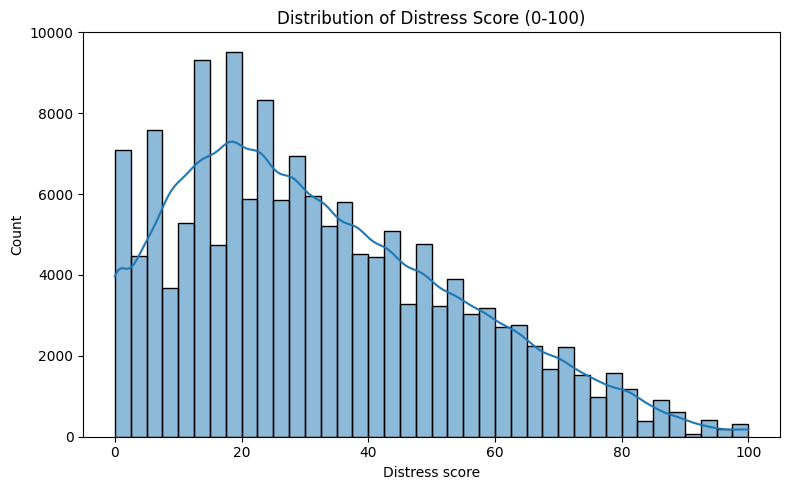

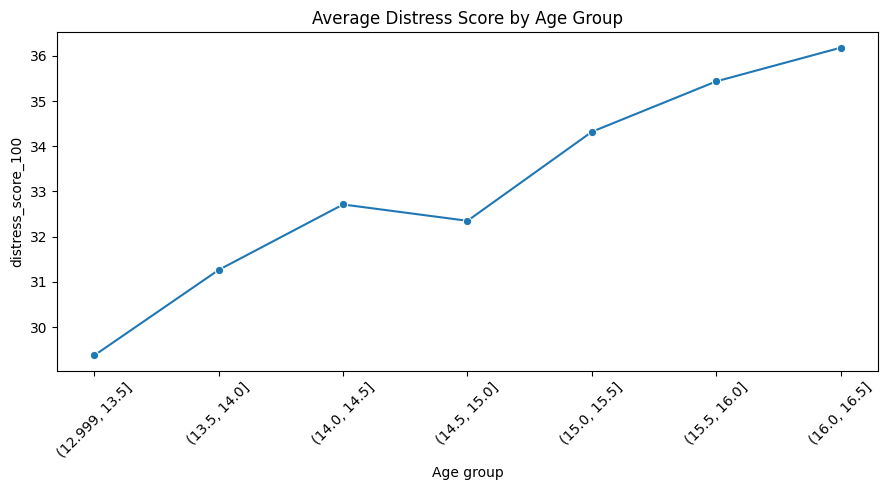

In [6]:
plt.figure(figsize=(8, 5))
sns.histplot(df_y["distress_score_100"], bins=40, kde=True)
plt.title("Distribution of Distress Score (0-100)")
plt.xlabel("Distress score")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

df_y["age_bin"] = pd.cut(df_y["age"], bins=np.arange(13, 16.6, 0.5), include_lowest=True)
age_bin_mean = (
    df_y.groupby("age_bin", dropna=False)[TARGET]
    .mean()
    .reset_index()
)
age_bin_mean["age_bin"] = age_bin_mean["age_bin"].astype(str)

plt.figure(figsize=(9, 5))
sns.lineplot(data=age_bin_mean, x="age_bin", y=TARGET, marker="o")
plt.title("Average Distress Score by Age Group")
plt.xlabel("Age group")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
print_header("BUILD FEATURES FROM WORKBOOK")

feature_plan = load_feature_plan(GROUPINGS_PATH)
feature_df, feature_cols, feature_manifest = build_feature_matrix(df_y, feature_plan)
existing_feature_names = [c for c in feature_df.columns if c in df_y.columns]
df_y = df_y.drop(columns=existing_feature_names, errors="ignore")
df_y = pd.concat([df_y, feature_df], axis=1)

print(f"Workbook rows kept for modelling: {(feature_plan['omit_for_modelling'] == 'N').sum()}")
print(f"Engineered feature count: {len(feature_cols)}")
print("\nFeature manifest:")
print(feature_manifest.to_string(index=False))

missing_features = feature_manifest[feature_manifest["missing_source_cols"] != ""]
if not missing_features.empty:
    print("\nWarning: some workbook source columns were missing from the dataset:")
    print(missing_features[["feature", "missing_source_cols"]].to_string(index=False))



BUILD FEATURES FROM WORKBOOK
Workbook rows kept for modelling: 72
Engineered feature count: 56

Feature manifest:
           feature feature_type                            source_cols      new_group                             aggregation_method long_term_var                                                                                                                   new_question missing_source_cols
               age   standalone                                    age                                                           raw             Y                                                                                                                                                   
               sex   standalone                                    sex                                                           raw             Y                                                                                                                                                   
   

In [8]:
print_header("DIRECTION AUDIT")
print(f"{'Feature':<30} {'Corr w/ distress':>16}  {'Direction':>10}")
print("-" * 60)

for col in feature_cols:
    valid = df_y[[col, TARGET]].dropna()
    if len(valid) > 100:
        r = valid[col].corr(valid[TARGET])
        direction = "+" if r > 0 else "-"
        print(f"{col:<30} {r:>+16.4f}  {direction}")


DIRECTION AUDIT
Feature                        Corr w/ distress   Direction
------------------------------------------------------------
age                                     +0.1084  +
sex                                     +0.2116  +
fasfamcar                               -0.0303  -
fasbedroom                              -0.0455  -
fascomputers                            +0.0014  +
fasbathroom                             -0.0149  -
fasdishwash                             -0.0139  -
fasholidays                             -0.0881  -
health                                  +0.3762  +
grp_aches                               -0.4948  -
sleepdificulty                          -0.4575  -
thinkbody                               +0.1479  +
physact60                               -0.1661  -
grp_bfast                               -0.2040  -
grp_fruits                              -0.1108  -
grp_sweets                              +0.0464  +
fmeal                                   +0.215

In [9]:
print_header("BUILD WORKING DATASET")

model_cols = list(dict.fromkeys(feature_cols + [TARGET]))
working_df = df_y[model_cols].copy()
working_df = working_df[working_df[TARGET].notna()].copy()

print("Working dataframe shape:", working_df.shape)
print("Features:", len(feature_cols))

working_df["age_band"] = pd.cut(
    working_df["age"],
    bins=[13, 14, 15, 16, 16.5],
    include_lowest=True
).astype(str)
working_df["sex_str"] = working_df["sex"].astype("Int64").astype(str)
working_df["strata"]  = working_df["age_band"] + "__" + working_df["sex_str"]

strata_counts = working_df["strata"].value_counts(dropna=False)
small_strata  = strata_counts[strata_counts < MIN_STRATUM_COUNT].index
working_df.loc[working_df["strata"].isin(small_strata), "strata"] = "other"

print("\nStrata counts:")
print(working_df["strata"].value_counts(dropna=False))

missing_pct = working_df[feature_cols].isnull().mean().sort_values(ascending=False)
print(f"\nMissing data % (top 15):")
print(missing_pct.head(15).to_string())


BUILD WORKING DATASET
Working dataframe shape: (150867, 57)
Features: 56

Strata counts:
strata
(12.999, 14.0]__2    35913
(12.999, 14.0]__1    34569
(15.0, 16.0]__2      31952
(15.0, 16.0]__1      29484
(14.0, 15.0]__2       7186
(14.0, 15.0]__1       6917
(16.0, 16.5]__1       2487
(16.0, 16.5]__2       2359
Name: count, dtype: int64

Missing data % (top 15):
bodyweight            0.146898
bodyheight            0.134363
emcsocmed8            0.113378
emcsocmed9            0.113007
emcsocmed7            0.112569
emcsocmed6            0.112443
emcsocmed5            0.111840
emcsocmed4            0.111661
emcsocmed3            0.110833
grp_online_pref       0.102726
grp_online_contact    0.092499
employfa              0.091306
employmo              0.090318
famdec                0.064613
teachertrust          0.062101



FEATURE CORRELATIONS
           feature  correlation  abs_corr      n
         grp_aches    -0.494757  0.494757 150860
    sleepdificulty    -0.457509  0.457509 147935
            health     0.376200  0.376200 150148
    schoolpressure     0.314931  0.314931 148625
   grp_talk_father     0.304354  0.304354 142521
       grp_fam_sup    -0.298862  0.298862 141660
        studaccept     0.294734  0.294734 141798
   grp_talk_mother     0.293306  0.293306 143900
        likeschool     0.278287  0.278287 148797
       grp_teacher     0.268312  0.268312 142198
      teachertrust     0.255469  0.255469 141498
       studhelpful     0.251761  0.251761 142124
  grp_been_bullied     0.247990  0.247990 147749
            famdec    -0.229586  0.229586 141119
      studtogether     0.218111  0.218111 142219
             fmeal     0.215241  0.215241 142353
               sex     0.211627  0.211627 150867
           famhelp    -0.205511  0.205511 141558
         grp_bfast    -0.204033  0.204033 14639

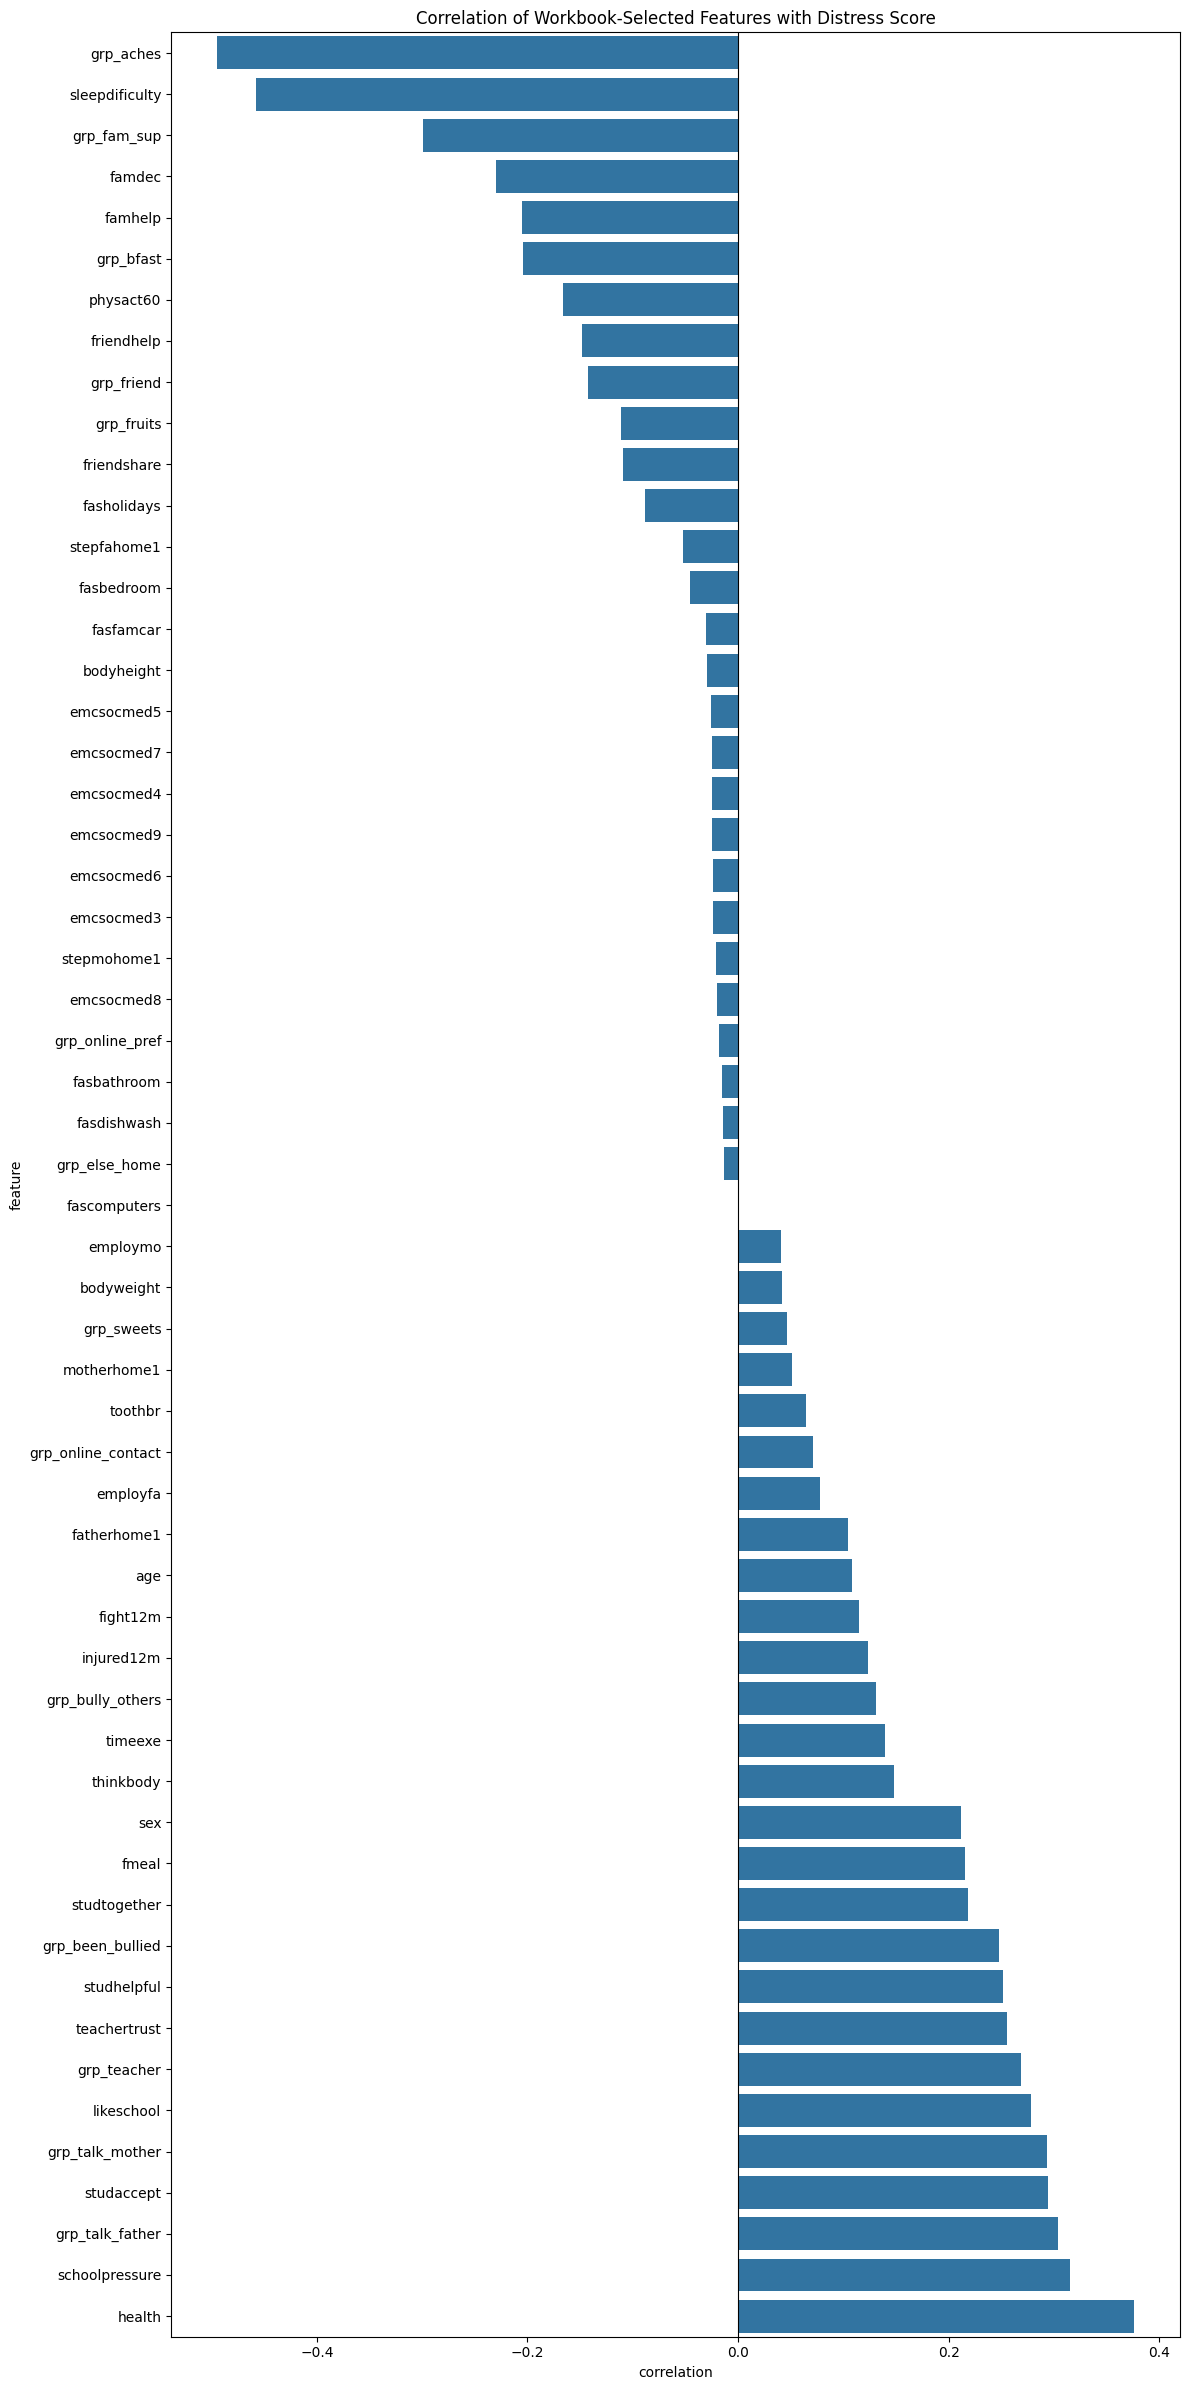

In [10]:
print_header("FEATURE CORRELATIONS")

corr_rows = []
for col in feature_cols:
    valid = working_df[[col, TARGET]].dropna()
    if len(valid) > 500:
        r = valid[col].corr(valid[TARGET])
        corr_rows.append({"feature": col, "correlation": r, "abs_corr": abs(r), "n": len(valid)})

corr_df = pd.DataFrame(corr_rows).sort_values("abs_corr", ascending=False)
print(corr_df.to_string(index=False))

plt.figure(figsize=(12, 24))
sns.barplot(data=corr_df.sort_values("correlation"), x="correlation", y="feature")
plt.title("Correlation of Workbook-Selected Features with Distress Score")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

In [11]:
print_header("DEFINE MODELS")

elasticnet_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("model",   ElasticNetCV(
        cv=5,
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0],
        n_alphas=100,
        max_iter=100000,
        random_state=42
    ))
])

rf_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model",   RandomForestRegressor(
        n_estimators=500,
        max_depth=15,
        min_samples_leaf=20,
        max_features="sqrt",
        n_jobs=-1,
        random_state=42,
    ))
])

print("ElasticNet pipeline ready.")
print("Random Forest pipeline ready.")


DEFINE MODELS
ElasticNet pipeline ready.
Random Forest pipeline ready.


In [12]:
print_header("HYPERPARAMETER TUNING")

X_all      = working_df[feature_cols].copy()
y_all      = working_df[TARGET].copy()
strata_all = working_df["strata"].copy()

for col in X_all.columns:
    X_all[col] = pd.to_numeric(X_all[col], errors="coerce")

drop_cols = X_all.columns[X_all.isnull().mean() > 0.95].tolist()
if drop_cols:
    print(f"Dropping {len(drop_cols)} columns (>95% missing): {drop_cols}")
    X_all = X_all.drop(columns=drop_cols)
    feature_cols = [c for c in feature_cols if c not in drop_cols]
    print(f"Features remaining: {len(feature_cols)}")

print(f"X_all shape before modelling: {X_all.shape}")
print("Reusing the original benrf.ipynb tuned RF hyperparameters to keep the v2 run tractable on the workbook-selected feature set.")

best_rf_params = {
    "n_estimators": 800,
    "min_samples_split": 5,
    "min_samples_leaf": 5,
    "max_features": 0.5,
    "max_depth": None,
    "n_jobs": -1,
    "random_state": 42,
}

print("Using RF params:")
for k, v in best_rf_params.items():
    print(f"  {k}: {v}")

tuned_rf_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model",   RandomForestRegressor(**best_rf_params))
])
print("\nTuned RF pipeline ready.")



HYPERPARAMETER TUNING
X_all shape before modelling: (150867, 56)
Reusing the original benrf.ipynb tuned RF hyperparameters to keep the v2 run tractable on the workbook-selected feature set.
Using RF params:
  n_estimators: 800
  min_samples_split: 5
  min_samples_leaf: 5
  max_features: 0.5
  max_depth: None
  n_jobs: -1
  random_state: 42

Tuned RF pipeline ready.


In [13]:
print_header("REPEATED OOS VALIDATIONS")

models = {
    "ElasticNet":   elasticnet_pipeline,
    "RandomForest": tuned_rf_pipeline,
}

all_oos_results = []
rf_importances = []

for model_name, base_model in models.items():
    print(f"\n--- {model_name} ---")
    for run_id, seed in enumerate(RANDOM_SEEDS[:N_OOS_RUNS], start=1):
        X_train, X_test, y_train, y_test, _, _ = train_test_split(
            X_all, y_all, strata_all,
            test_size=TEST_SIZE, random_state=seed, stratify=strata_all
        )

        m = clone(base_model)
        m.fit(X_train, y_train)

        y_pred_train = m.predict(X_train)
        y_pred_test  = m.predict(X_test)

        row = {
            "model":      model_name,
            "run":        run_id,
            "seed":       seed,
            "train_r2":   r2_score(y_train, y_pred_train),
            "test_r2":    r2_score(y_test, y_pred_test),
            "train_rmse": rmse(y_train, y_pred_train),
            "test_rmse":  rmse(y_test, y_pred_test),
            "train_mae":  mean_absolute_error(y_train, y_pred_train),
            "test_mae":   mean_absolute_error(y_test, y_pred_test),
        }
        all_oos_results.append(row)

        if model_name == "RandomForest":
            imp = m.named_steps["model"].feature_importances_
            rf_importances.append(pd.DataFrame({
                "run": run_id, "feature": feature_cols, "importance": imp
            }))

        print(f"  Run {run_id}: train_r2={row['train_r2']:.4f}, test_r2={row['test_r2']:.4f}, test_rmse={row['test_rmse']:.2f}")

oos_df = pd.DataFrame(all_oos_results)


REPEATED OOS VALIDATIONS

--- ElasticNet ---
  Run 1: train_r2=0.4892, test_r2=0.4866, test_rmse=15.68
  Run 2: train_r2=0.4911, test_r2=0.4785, test_rmse=15.77
  Run 3: train_r2=0.4879, test_r2=0.4909, test_rmse=15.62
  Run 4: train_r2=0.4857, test_r2=0.5003, test_rmse=15.49
  Run 5: train_r2=0.4900, test_r2=0.4826, test_rmse=15.66

--- RandomForest ---
  Run 1: train_r2=0.7855, test_r2=0.5020, test_rmse=15.45
  Run 2: train_r2=0.7864, test_r2=0.4914, test_rmse=15.57
  Run 3: train_r2=0.7851, test_r2=0.5063, test_rmse=15.38
  Run 4: train_r2=0.7842, test_r2=0.5127, test_rmse=15.30
  Run 5: train_r2=0.7863, test_r2=0.4946, test_rmse=15.48



MODEL COMPARISON
              mean_test_r2  std_test_r2  mean_test_rmse  std_test_rmse  mean_test_mae  std_test_mae  mean_train_r2
model                                                                                                             
ElasticNet          0.4878       0.0084         15.6432         0.1017        12.3174        0.0685         0.4888
RandomForest        0.5014       0.0086         15.4342         0.1036        12.1389        0.0628         0.7855

R2 improvement:   0.4878 -> 0.5014 (+0.0136)
RMSE improvement: 15.64 -> 15.43 (-0.21)


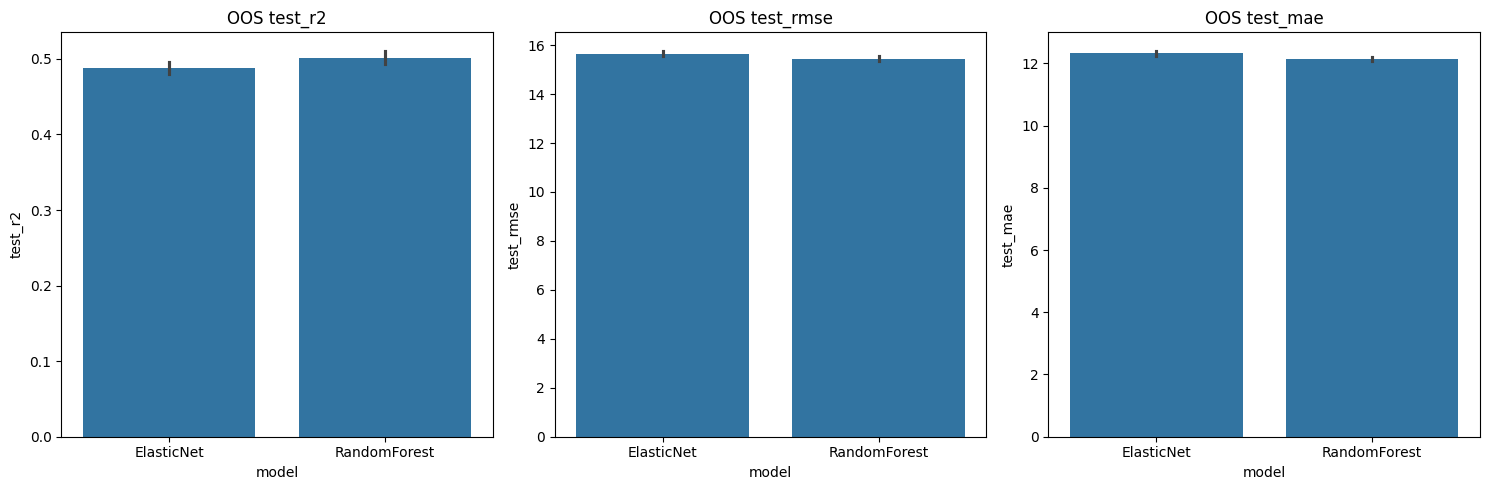

In [14]:
print_header("MODEL COMPARISON")

comparison = (
    oos_df.groupby("model")
    .agg(
        mean_test_r2   = ("test_r2",   "mean"),
        std_test_r2    = ("test_r2",   "std"),
        mean_test_rmse = ("test_rmse", "mean"),
        std_test_rmse  = ("test_rmse", "std"),
        mean_test_mae  = ("test_mae",  "mean"),
        std_test_mae   = ("test_mae",  "std"),
        mean_train_r2  = ("train_r2",  "mean"),
    )
    .round(4)
)
print(comparison.to_string())

en_r2   = comparison.loc["ElasticNet",   "mean_test_r2"]
rf_r2   = comparison.loc["RandomForest", "mean_test_r2"]
en_rmse = comparison.loc["ElasticNet",   "mean_test_rmse"]
rf_rmse = comparison.loc["RandomForest", "mean_test_rmse"]

print(f"\nR2 improvement:   {en_r2:.4f} -> {rf_r2:.4f} (+{rf_r2 - en_r2:.4f})")
print(f"RMSE improvement: {en_rmse:.2f} -> {rf_rmse:.2f} ({rf_rmse - en_rmse:.2f})")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, metric in enumerate(["test_r2", "test_rmse", "test_mae"]):
    sns.barplot(data=oos_df, x="model", y=metric, ax=axes[i], errorbar="sd")
    axes[i].set_title(f"OOS {metric}")
plt.tight_layout()
plt.show()


FEATURE IMPORTANCE
           feature  mean_importance  std_importance
         grp_aches         0.213173        0.001270
    sleepdificulty         0.143257        0.001170
            health         0.067334        0.001217
       grp_fam_sup         0.051785        0.001342
    schoolpressure         0.039686        0.000471
   grp_talk_father         0.033405        0.001857
               age         0.024013        0.000176
        bodyheight         0.019684        0.000104
        bodyweight         0.019501        0.000227
        emcsocmed8         0.018768        0.000699
   grp_talk_mother         0.018355        0.000688
        studaccept         0.016611        0.000505
grp_online_contact         0.016178        0.000162
        grp_sweets         0.015935        0.000154
   grp_online_pref         0.015793        0.000212
        likeschool         0.015439        0.000558
        grp_fruits         0.015364        0.000098
         physact60         0.015143        0

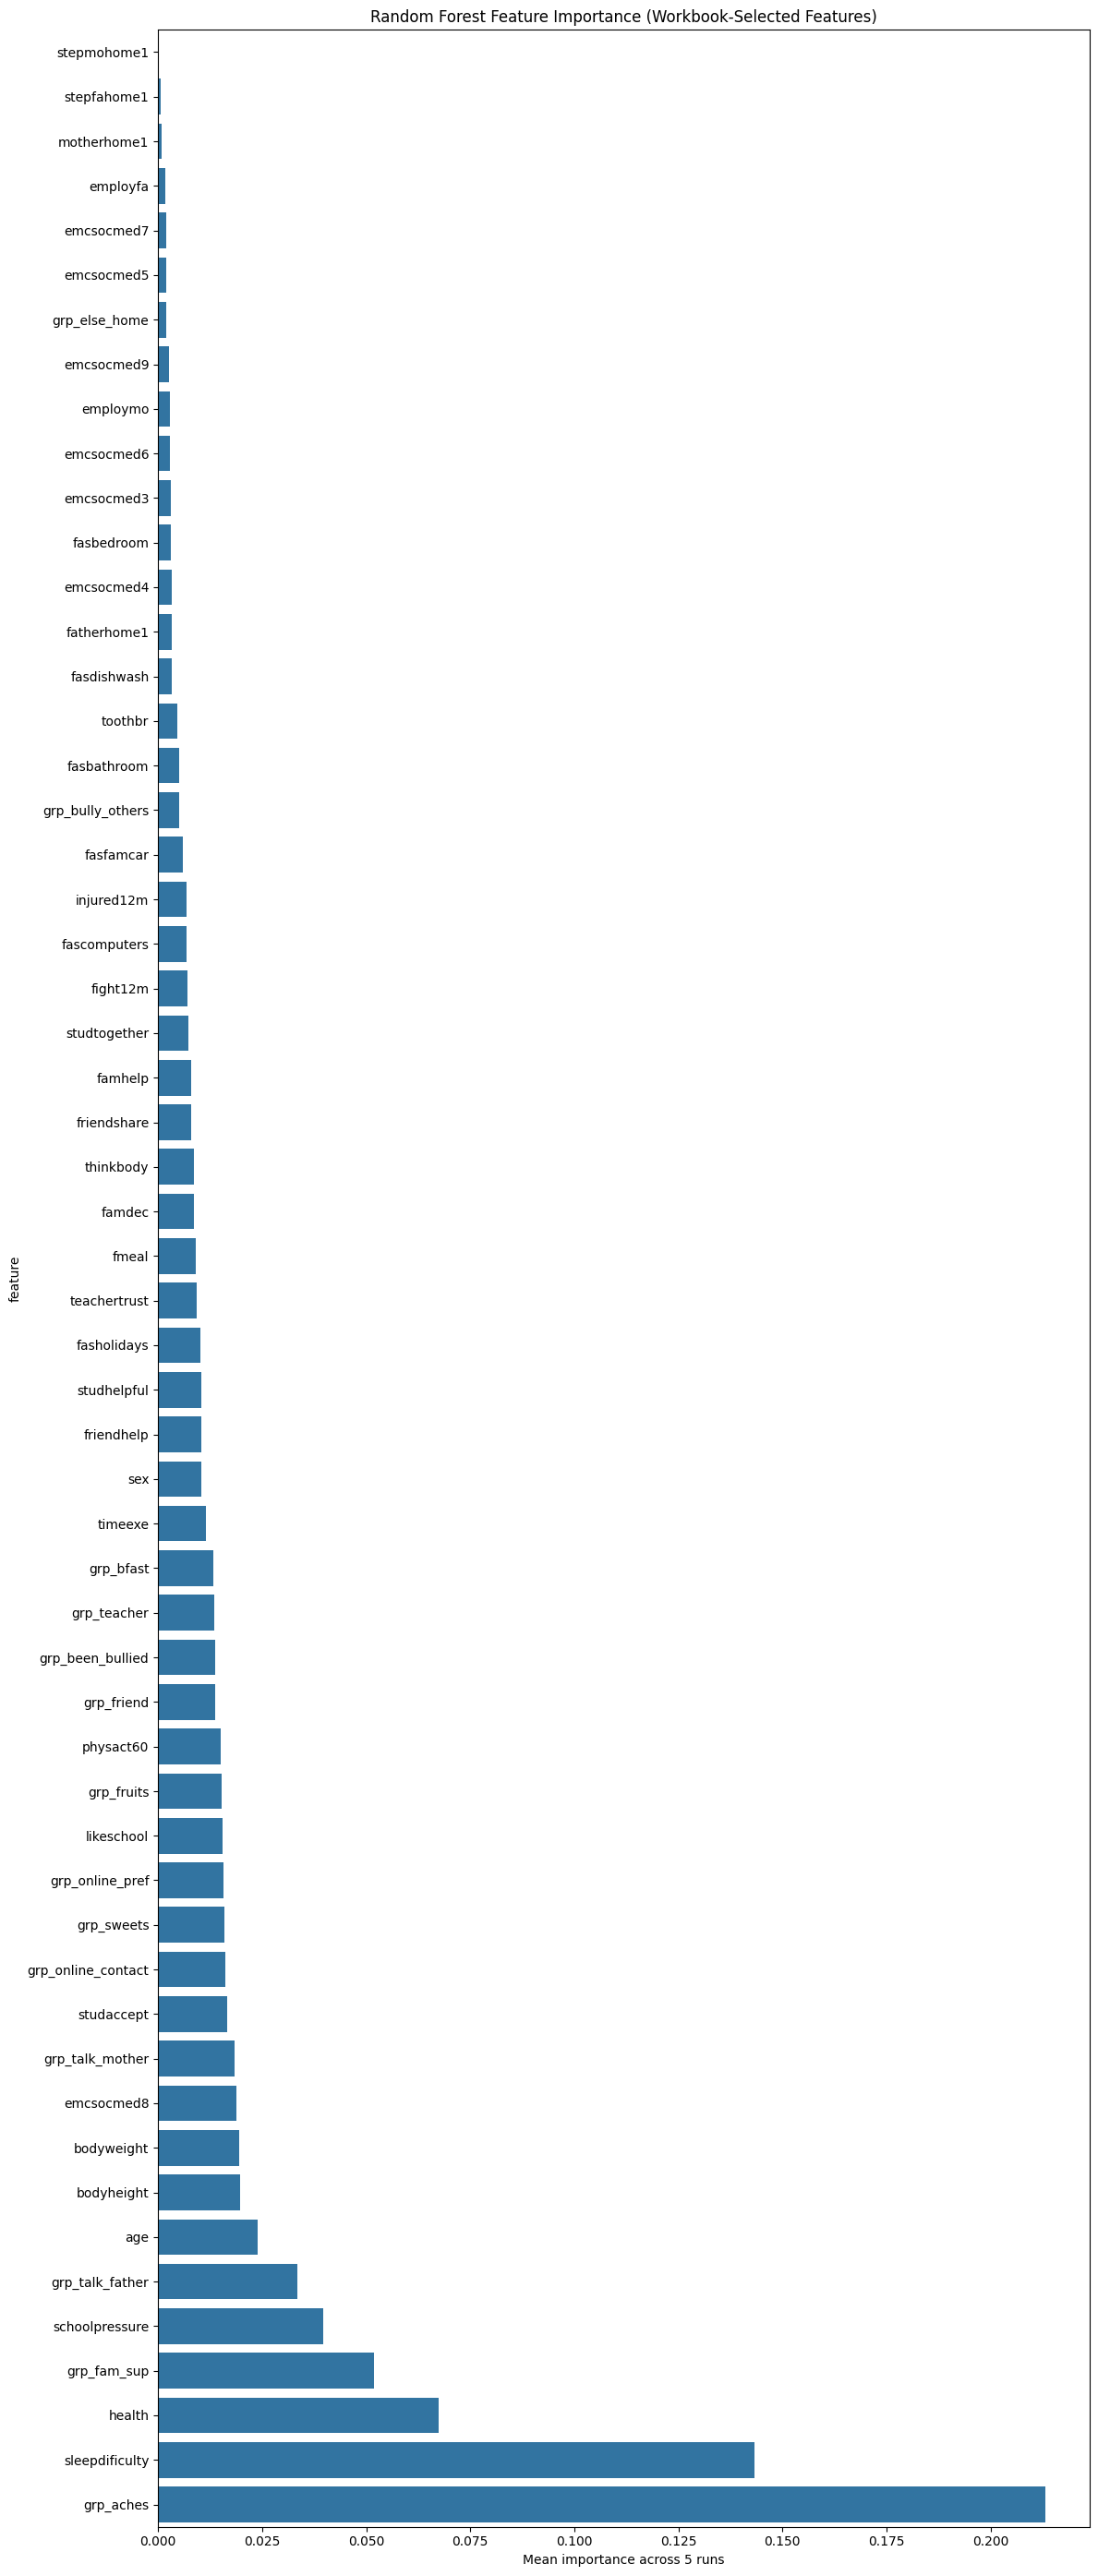

In [15]:
print_header("FEATURE IMPORTANCE")

imp_df = pd.concat(rf_importances, ignore_index=True)
imp_summary = (
    imp_df.groupby("feature")
    .agg(
        mean_importance = ("importance", "mean"),
        std_importance  = ("importance", "std"),
    )
    .sort_values("mean_importance", ascending=False)
    .reset_index()
)

print(imp_summary.to_string(index=False))

plt.figure(figsize=(12, 28))
sns.barplot(
    data=imp_summary.sort_values("mean_importance", ascending=True),
    x="mean_importance", y="feature"
)
plt.title("Random Forest Feature Importance (Workbook-Selected Features)")
plt.xlabel("Mean importance across 5 runs")
plt.tight_layout()
plt.show()

In [16]:
print_header("FINAL MODEL ON FULL SAMPLE")

final_rf = clone(tuned_rf_pipeline)
final_rf.fit(X_all, y_all)

full_pred = final_rf.predict(X_all)
diagnostic_df = working_df.copy()
diagnostic_df["predicted_distress"] = full_pred
diagnostic_df["residual"]           = full_pred - diagnostic_df[TARGET]
diagnostic_df["abs_error"]          = diagnostic_df["residual"].abs()

in_sample_r2 = r2_score(diagnostic_df[TARGET], full_pred)
rf_mean_oos = oos_df[oos_df["model"] == "RandomForest"]["test_r2"].mean()
print(f"In-sample R2: {in_sample_r2:.4f}")
print(f"Mean OOS R2:  {rf_mean_oos:.4f}")
print(f"Overfit gap:  {in_sample_r2 - rf_mean_oos:.4f}")


FINAL MODEL ON FULL SAMPLE
In-sample R2: 0.7861
Mean OOS R2:  0.5014
Overfit gap:  0.2847


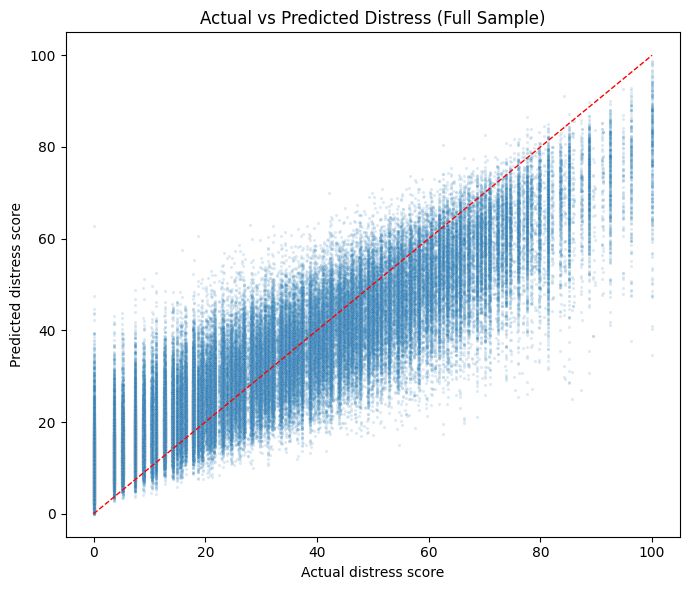

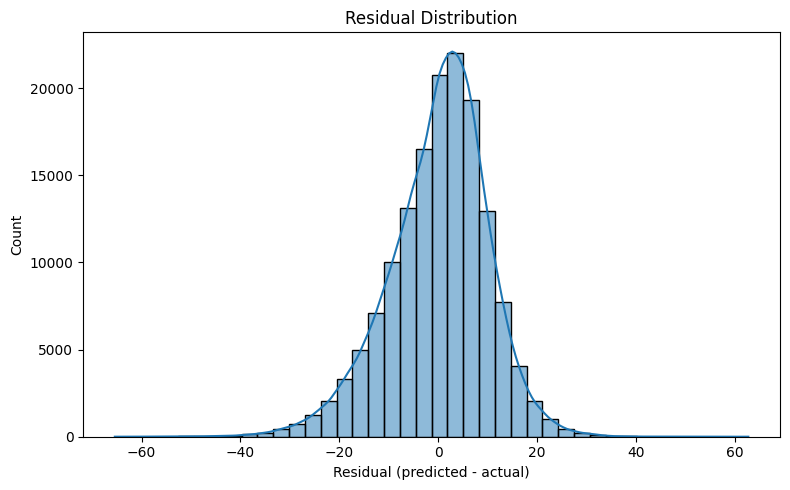

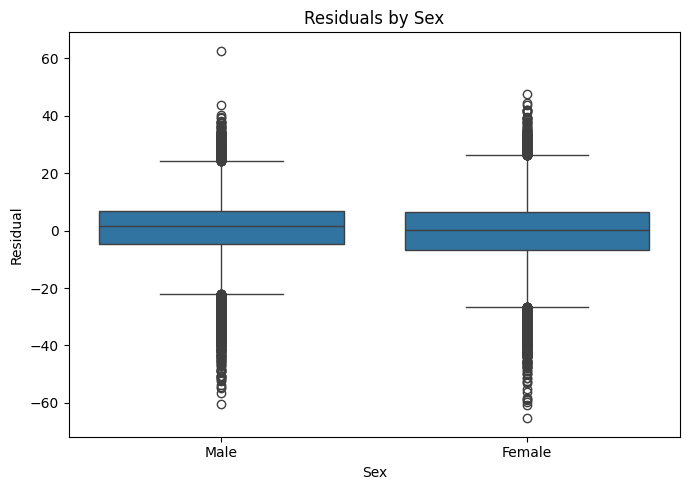

In [17]:
plt.figure(figsize=(7, 6))
sns.scatterplot(
    x=diagnostic_df[TARGET],
    y=diagnostic_df["predicted_distress"],
    alpha=0.15, s=5
)
lo = min(diagnostic_df[TARGET].min(), diagnostic_df["predicted_distress"].min())
hi = max(diagnostic_df[TARGET].max(), diagnostic_df["predicted_distress"].max())
plt.plot([lo, hi], [lo, hi], linestyle="--", color="red", linewidth=1)
plt.title("Actual vs Predicted Distress (Full Sample)")
plt.xlabel("Actual distress score")
plt.ylabel("Predicted distress score")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(diagnostic_df["residual"], bins=40, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residual (predicted - actual)")
plt.tight_layout()
plt.show()

if "sex" in diagnostic_df.columns:
    plt.figure(figsize=(7, 5))
    sns.boxplot(
        data=diagnostic_df,
        x=diagnostic_df["sex"].map({1: "Male", 2: "Female"}),
        y="residual"
    )
    plt.title("Residuals by Sex")
    plt.xlabel("Sex")
    plt.ylabel("Residual")
    plt.tight_layout()
    plt.show()

In [18]:
print_header("SAVE OUTPUTS")

output_files = {
    "oos": f"{OUTPUT_PREFIX}_oos_results.csv",
    "comparison": f"{OUTPUT_PREFIX}_vs_elasticnet_comparison.csv",
    "importance": f"{OUTPUT_PREFIX}_feature_importance.csv",
    "predictions": f"{OUTPUT_PREFIX}_final_predictions.csv",
    "manifest": f"{OUTPUT_PREFIX}_feature_manifest.csv",
}

oos_df.to_csv(output_files["oos"], index=False)
comparison.to_csv(output_files["comparison"])
imp_summary.to_csv(output_files["importance"], index=False)
diagnostic_df.to_csv(output_files["predictions"], index=False)
feature_manifest.to_csv(output_files["manifest"], index=False)

print("Saved:")
for f in output_files.values():
    print(" -", f)



SAVE OUTPUTS
Saved:
 - benrfv2_oos_results.csv
 - benrfv2_vs_elasticnet_comparison.csv
 - benrfv2_feature_importance.csv
 - benrfv2_final_predictions.csv
 - benrfv2_feature_manifest.csv


In [19]:
print_header("SUMMARY")

rf_oos = oos_df[oos_df["model"] == "RandomForest"]
en_oos = oos_df[oos_df["model"] == "ElasticNet"]

print(f"Feature count used: {len(feature_cols)}")
print("\nRandom Forest")
print(f"  Mean OOS R2:   {rf_oos['test_r2'].mean():.4f} +/- {rf_oos['test_r2'].std():.4f}")
print(f"  Mean OOS RMSE: {rf_oos['test_rmse'].mean():.2f} +/- {rf_oos['test_rmse'].std():.2f}")
print(f"  Mean OOS MAE:  {rf_oos['test_mae'].mean():.2f} +/- {rf_oos['test_mae'].std():.2f}")

print("\nElasticNet")
print(f"  Mean OOS R2:   {en_oos['test_r2'].mean():.4f} +/- {en_oos['test_r2'].std():.4f}")
print(f"  Mean OOS RMSE: {en_oos['test_rmse'].mean():.2f} +/- {en_oos['test_rmse'].std():.2f}")
print(f"  Mean OOS MAE:  {en_oos['test_mae'].mean():.2f} +/- {en_oos['test_mae'].std():.2f}")

print(f"\nR2:   {en_oos['test_r2'].mean():.4f} -> {rf_oos['test_r2'].mean():.4f} (+{rf_oos['test_r2'].mean() - en_oos['test_r2'].mean():.4f})")
print(f"RMSE: {en_oos['test_rmse'].mean():.2f} -> {rf_oos['test_rmse'].mean():.2f} ({rf_oos['test_rmse'].mean() - en_oos['test_rmse'].mean():.2f})")

print("\nAll features by importance:")
print(imp_summary.to_string(index=False))



SUMMARY
Feature count used: 56

Random Forest
  Mean OOS R2:   0.5014 +/- 0.0086
  Mean OOS RMSE: 15.43 +/- 0.10
  Mean OOS MAE:  12.14 +/- 0.06

ElasticNet
  Mean OOS R2:   0.4878 +/- 0.0084
  Mean OOS RMSE: 15.64 +/- 0.10
  Mean OOS MAE:  12.32 +/- 0.07

R2:   0.4878 -> 0.5014 (+0.0136)
RMSE: 15.64 -> 15.43 (-0.21)

All features by importance:
           feature  mean_importance  std_importance
         grp_aches         0.213173        0.001270
    sleepdificulty         0.143257        0.001170
            health         0.067334        0.001217
       grp_fam_sup         0.051785        0.001342
    schoolpressure         0.039686        0.000471
   grp_talk_father         0.033405        0.001857
               age         0.024013        0.000176
        bodyheight         0.019684        0.000104
        bodyweight         0.019501        0.000227
        emcsocmed8         0.018768        0.000699
   grp_talk_mother         0.018355        0.000688
        studaccept         